In [2]:
#import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [3]:
#import the data set
data = pd.read_csv("C:/Users/maaduchathurya/OneDrive/文档\crt techincal/diabetes.csv")

In [4]:
data.shape

(2000, 9)

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               2000 non-null   int64  
 1   Glucose                   2000 non-null   int64  
 2   BloodPressure             2000 non-null   int64  
 3   SkinThickness             2000 non-null   int64  
 4   Insulin                   2000 non-null   int64  
 5   BMI                       2000 non-null   float64
 6   DiabetesPedigreeFunction  2000 non-null   float64
 7   Age                       2000 non-null   int64  
 8   Outcome                   2000 non-null   int64  
dtypes: float64(2), int64(7)
memory usage: 140.8 KB


In [6]:
data.sample()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
1070,6,105,80,28,0,32.5,0.878,26,0


In [7]:
data.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,3.703500,121.182500,69.145500,20.935000,80.254000,32.193000,0.470930,33.090500,0.342000
std,3.306063,32.068636,19.188315,16.103243,111.180534,8.149901,0.323553,11.786423,0.474498
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,63.500000,0.000000,0.000000,27.375000,0.244000,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,40.000000,32.300000,0.376000,29.000000,0.000000
75%,6.000000,141.000000,80.000000,32.000000,130.000000,36.800000,0.624000,40.000000,1.000000
max,17.000000,199.000000,122.000000,110.000000,744.000000,80.600000,2.420000,81.000000,1.000000


In [8]:
#checking missing values
data.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [9]:
#coleration 
data.corr()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.000000,0.120405,0.149672,-0.063375,-0.076600,0.019475,-0.025453,0.539457,0.224437
Glucose,0.120405,1.000000,0.138044,0.062368,0.320371,0.226864,0.123243,0.254496,0.458421
BloodPressure,0.149672,0.138044,1.000000,0.198800,0.087384,0.281545,0.051331,0.238375,0.075958
SkinThickness,-0.063375,0.062368,0.198800,1.000000,0.448859,0.393760,0.178299,-0.111034,0.076040
Insulin,-0.076600,0.320371,0.087384,0.448859,1.000000,0.223012,0.192719,-0.085879,0.120924
BMI,0.019475,0.226864,0.281545,0.393760,0.223012,1.000000,0.125719,0.038987,0.276726
DiabetesPedigreeFunction,-0.025453,0.123243,0.051331,0.178299,0.192719,0.125719,1.000000,0.026569,0.155459
Age,0.539457,0.254496,0.238375,-0.111034,-0.085879,0.038987,0.026569,1.000000,0.236509
Outcome,0.224437,0.458421,0.075958,0.076040,0.120924,0.276726,0.155459,0.236509,1.000000


In [10]:
#step1: independent and dependent variable creation 
x=data[['Pregnancies','Glucose','BloodPressure','SkinThickness','Insulin','BMI','DiabetesPedigreeFunction','Age']]# variables contains one feature
y=data.Outcome#y is target
x

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,2,138,62,35,0,33.6,0.127,47
1,0,84,82,31,125,38.2,0.233,23
2,0,145,0,0,0,44.2,0.630,31
3,0,135,68,42,250,42.3,0.365,24
4,1,139,62,41,480,40.7,0.536,21
...,...,...,...,...,...,...,...,...
1995,2,75,64,24,55,29.7,0.370,33
1996,8,179,72,42,130,32.7,0.719,36
1997,6,85,78,0,0,31.2,0.382,42
1998,0,129,110,46,130,67.1,0.319,26


In [11]:
from sklearn .model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=4)

In [12]:
print(len(x_test))
print(len(x_train))

400
1600


In [13]:
#step3 creating model
from sklearn.metrics import r2_score
from sklearn.linear_model import LinearRegression
LR=LinearRegression() #object creation
LR.fit(x_train,y_train) #training of linear regression
y_predict=LR.predict(x_test)
print("R2 : ",r2_score(y_test,y_predict))

R2 :  0.29738369267790077


In [14]:
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error,root_mean_squared_error
r2score=r2_score(y_test,y_predict)
r2score

0.29738369267790077

In [15]:
print("MSE :",mean_squared_error(y_test,y_predict))
print("MAE :",mean_absolute_error(y_test,y_predict))
print("MRSE :",root_mean_squared_error(y_test,y_predict))

MSE : 0.1565253478636807
MAE : 0.3318725236393609
MRSE : 0.3956328447736369


In [16]:
# train the model
from sklearn.linear_model import LogisticRegression
#load the model
model=LogisticRegression()
#fit the model
train_model=model.fit(x_train,y_train)
#make predictions
y_pred=train_model.predict(x_test)
y_pred

array([1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0,
       0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0,
       1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0,
       0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1,
       0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1,
       1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1,

In [17]:
#find accuracy
from sklearn.metrics import accuracy_score
accuracy=accuracy_score(y_test,y_pred)
print("accuracy of Logestic Regression model is :",accuracy)

accuracy of Logestic Regression model is : 0.7725


In [18]:
# check the loss function
from sklearn.metrics import log_loss
log_loss=log_loss(y_test,y_pred)
print("log loss of logistic regression model is:",log_loss)

log loss of logistic regression model is: 8.199931146024152


In [19]:
#combined actual vs predicted
comparison=pd.DataFrame({"Actual":y_test,"predicted":y_pred})
comparison

,Actual,predicted
1893,1,1
898,0,0
1578,0,0
559,0,0
88,1,1
...,...,...
570,0,0
376,0,0
1249,1,0
492,0,0


In [28]:
#finding the confusion matrix
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test,y_pred)
cm

array([[232,  34],
       [ 57,  77]])

In [29]:
train_accuracy=model.score(x_train,y_train)
print("traing accuracy:",train_accuracy)

traing accuracy: 0.788125


In [30]:
test_accuracy=model.score(x_test,y_test)
print("testing accuracy:",test_accuracy)

testing accuracy: 0.7725


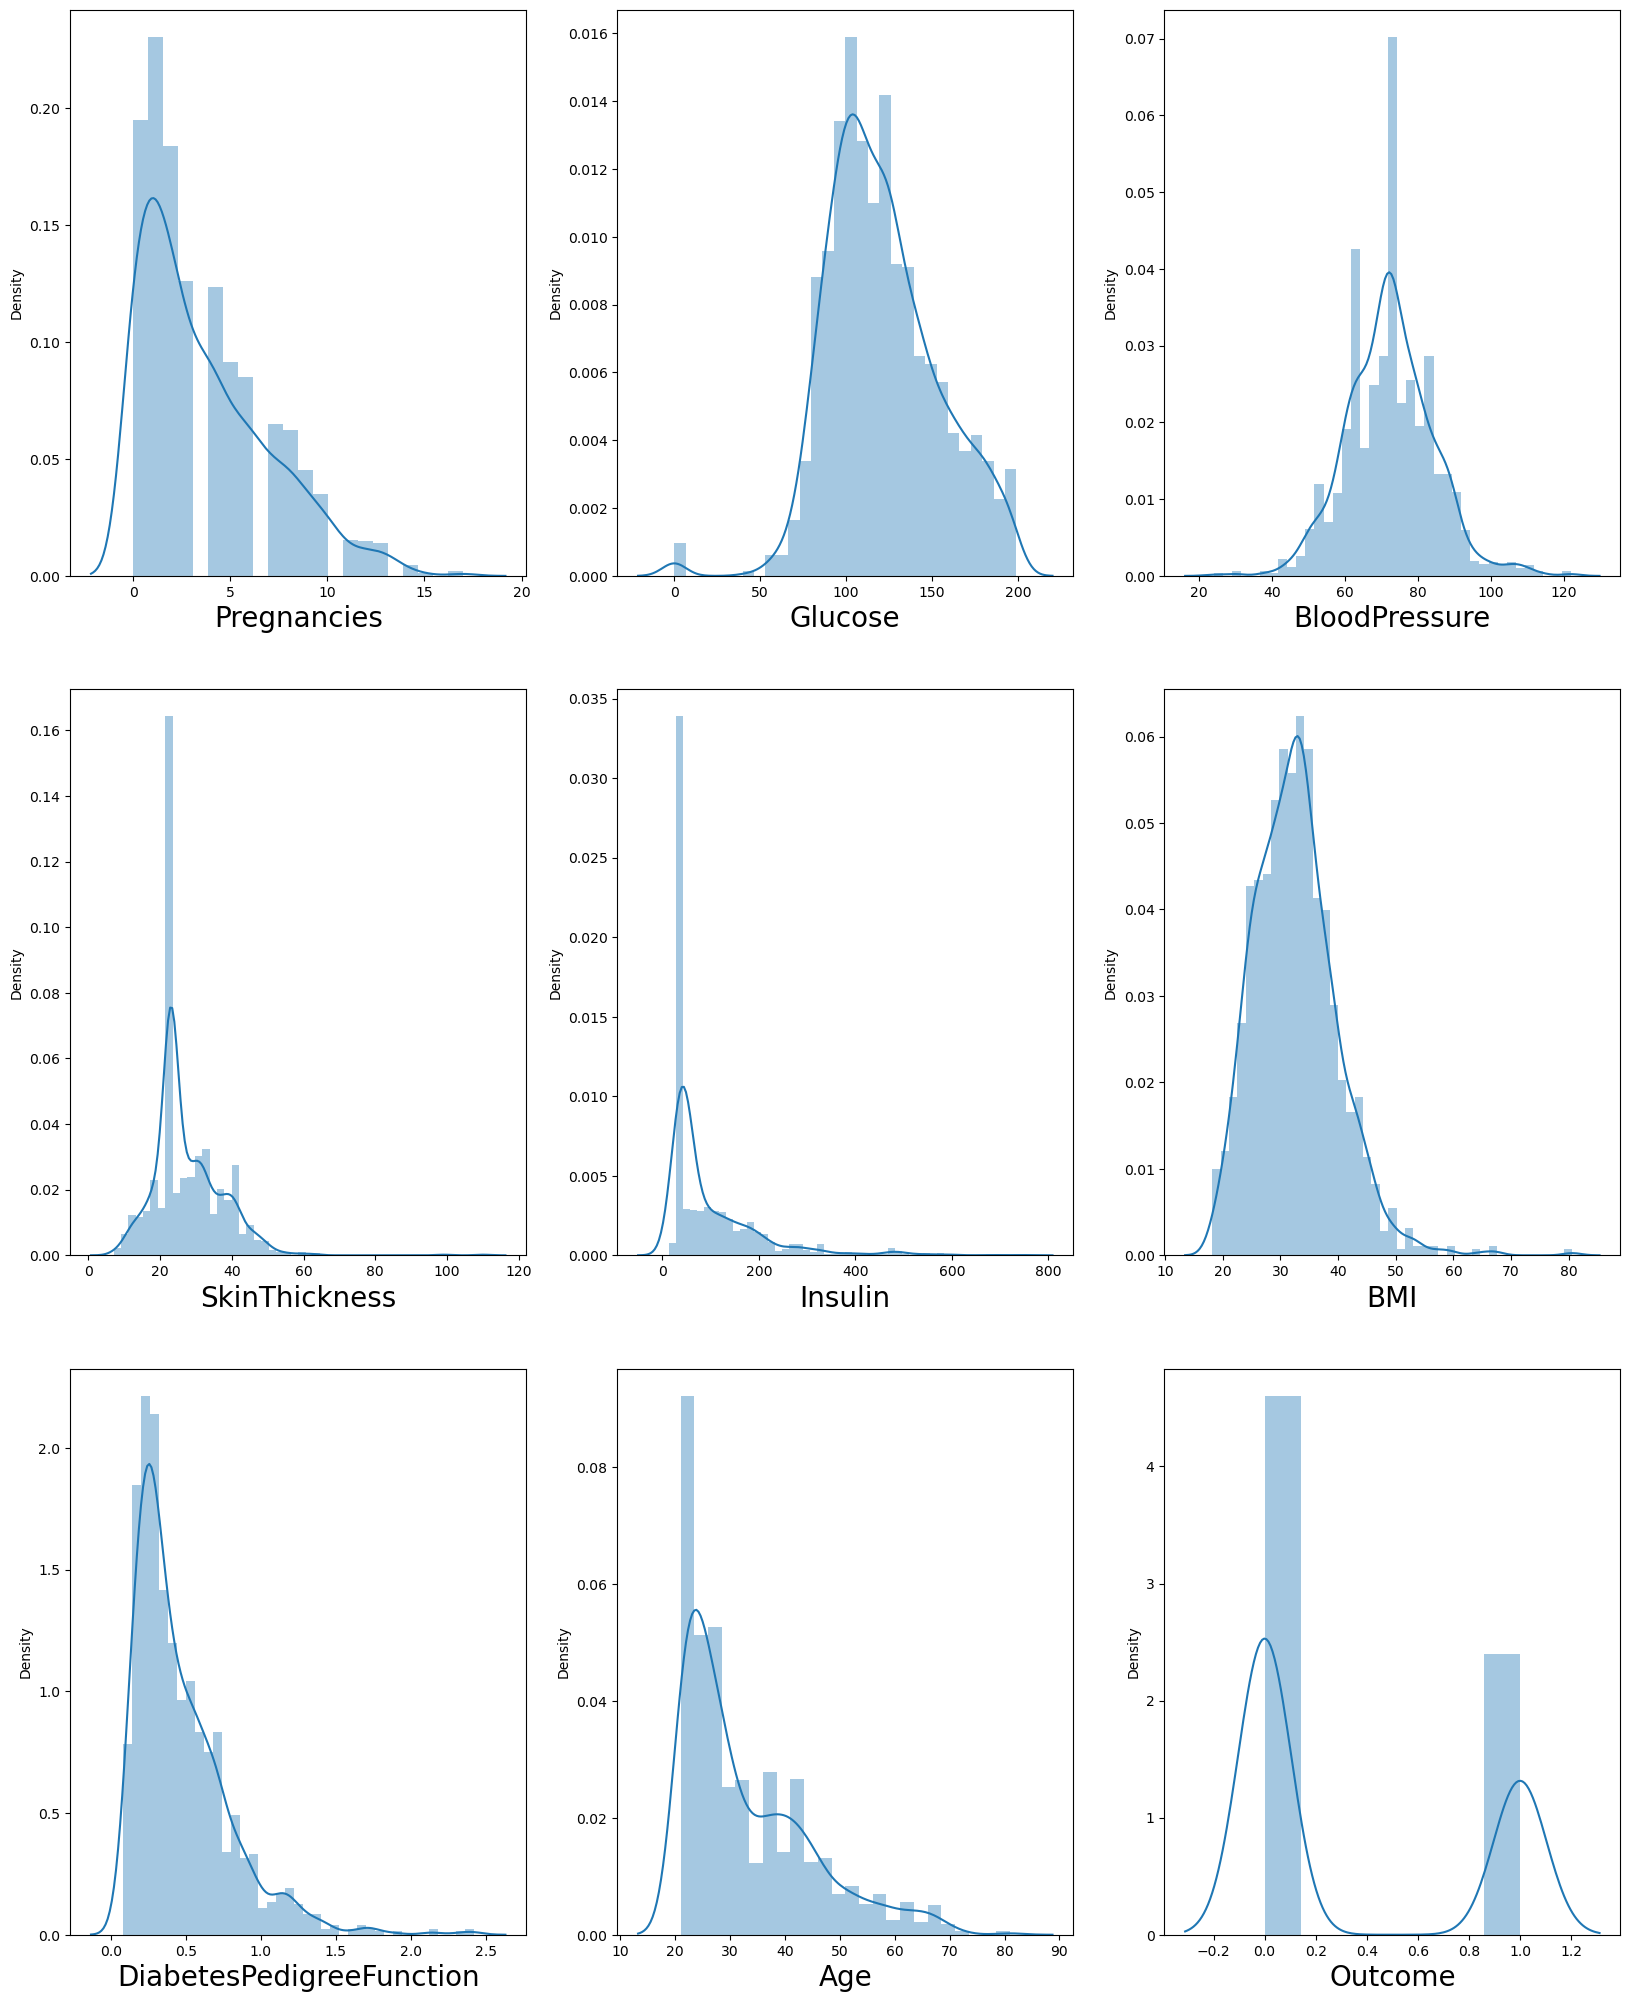

In [31]:
#let's see how data is distributed for rvery column
plt.figure(figsize=(20,25),facecolor='white')
plotnumber=1
for column in data:
    if plotnumber<=9:   #as there are 9 columns in the data
        ax=plt.subplot(3,3,plotnumber)
        sns.distplot(data[column])
        plt.xlabel(column,fontsize=20)
        #plot .ylabel('',fontsize=20)
    plotnumber+=1
plt.show()

In [32]:
#replacing zero columns with mean and median 
data['BMI']=data['BMI'].replace(0,data['BMI'].median())
data['BloodPressure']=data['BloodPressure'].replace(0,data['BloodPressure'].median())
data['Insulin']=data['Insulin'].replace(0,data['Insulin'].median())
data['SkinThickness']=data['SkinThickness'].replace(0,data['SkinThickness'].median())


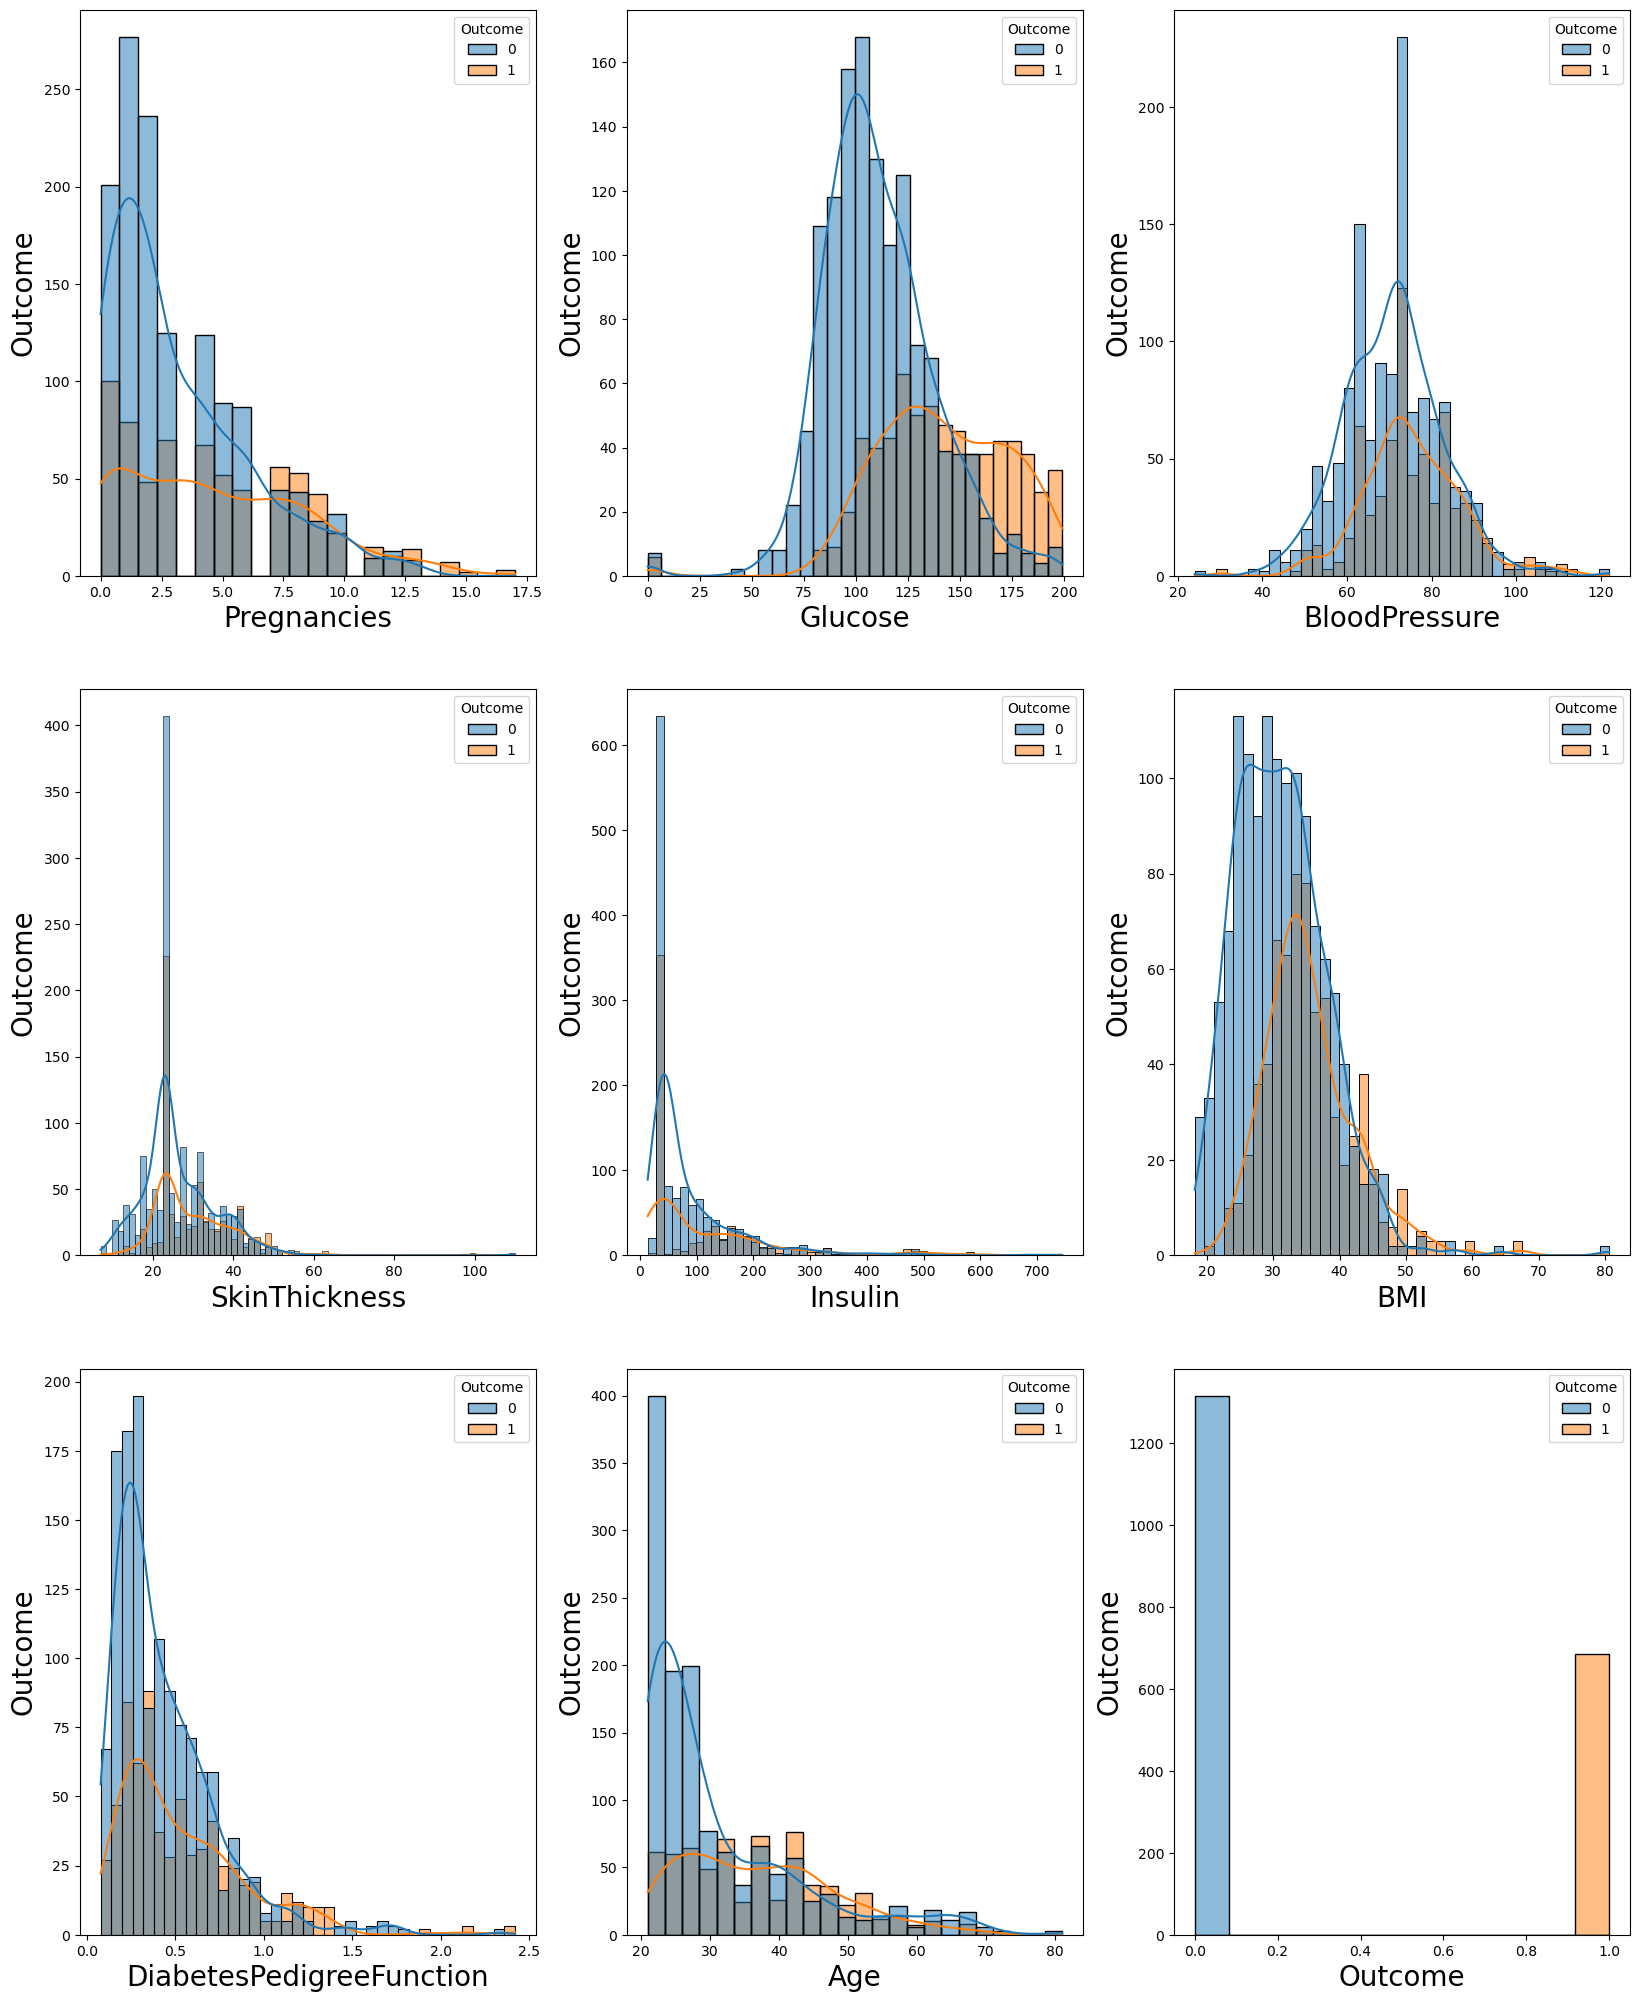

In [33]:
#let's see how data is distributed for rvery column
plt.figure(figsize=(20,25),facecolor='white')
plotnumber=1
for column in data:
    if plotnumber<=9:   #as there are 9 columns in the data
        ax=plt.subplot(3,3,plotnumber)
        sns.histplot(data=data, x=column, hue='Outcome', kde=True)
        plt.xlabel(column,fontsize=20)
        plt .ylabel('Outcome',fontsize=20)
    plotnumber+=1
plt.show()

In [ ]:
#insights for the above graph 
1.Pregnancies – Higher number of pregnancies is more common in Outcome = 1, indicating increased diabetes risk with more pregnancies.
2.Glucose – Clear separation shows higher glucose levels strongly associated with Outcome = 1, making it the most important predictor.
3.BloodPressure – Both outcomes overlap heavily, suggesting blood pressure alone is a weak indicator of diabetes.
4.SkinThickness – Outcome = 1 tends to have slightly higher skin thickness, but with significant overlap.
5.Insulin – Highly right-skewed with many zeros; higher insulin values are more frequent in Outcome = 1, but data is noisy.
6.BMI – Diabetic patients (Outcome = 1) generally have higher BMI, showing a strong positive relationship.
7.DiabetesPedigreeFunction – Higher values are more common for Outcome = 1, indicating genetic influence on diabetes.
8.Age – Diabetes prevalence increases with age; older individuals are more likely to have Outcome = 1.
9.Outcome – Dataset is imbalanced, with more non-diabetic (0) cases than diabetic (1)
* Overall Insight:
Glucose, BMI, Age, and Pregnancies show the strongest relationship with diabetes, while BloodPressure and SkinThickness contribute less individually.


In [34]:
from scipy import stats
import statsmodels.api as sm
Glucose_pos=data[data['Outcome']==1]['Glucose']
Glucose_negative=data[data['Outcome']==0]['Glucose']

In [35]:
t_stat,p_val=stats.ttest_ind(Glucose_pos,Glucose_pos)
print("Independent T-Test statistic :",t_stat)
print("p-value:",p_val)
if p_val <0.05:
    print("Reject null hypothesis:")
else:
    print("fail to reject null hypothesis:")

Independent T-Test statistic : 0.0
p-value: 1.0
fail to reject null hypothesis:


#T-Test
*definition:*t-Test is used to compare means when the population variance is unknow or the sample size is small.

---
##Independent T-Tesst
**EWxample:** compare **Glucose** of **positive vs Negative** person
**hypotheses:**
-H0:glucose distribution of positive =Glucose distribution of negative
-H1:glucose distribution of positive !=Glucose distribution of negative

In [36]:
t_stat,p_val=stats.ttest_ind(Glucose_pos,Glucose_negative)
print("Independent T-Test statistic :",t_stat)
print("p-value:",p_val)
if p_val <0.05:
    print("Reject null hypothesis:")
else:
    print("fail to reject null hypothesis:")

Independent T-Test statistic : 23.05633354719803
p-value: 1.724006801539328e-104
Reject null hypothesis:


In [37]:
Pregnancies_pos=data[data['Outcome']==1]['Pregnancies']
Pregnancies_negative=data[data['Outcome']==0]['Pregnancies']

In [38]:
t_stat,p_val=stats.ttest_ind(Pregnancies_pos,Pregnancies_negative)
print("Independent T-Test statistic :",t_stat)
print("p-value:",p_val)
if p_val <0.05:
    print("Reject null hypothesis:")
else:
    print("fail to reject null hypothesis:")

Independent T-Test statistic : 10.294740851256517
p-value: 2.968017579508808e-24
Reject null hypothesis:


In [39]:
BloodPressure_pos=data[data['Outcome']==1]['BloodPressure']
BloodPressure_negative=data[data['Outcome']==0]['BloodPressure']

In [40]:
t_stat,p_val=stats.ttest_ind(BloodPressure_pos,BloodPressure_negative)
print("Independent T-Test statistic :",t_stat)
print("p-value:",p_val)
if p_val <0.05:
    print("Reject null hypothesis:")
else:
    print("fail to reject null hypothesis:")

Independent T-Test statistic : 7.906717522386685
p-value: 4.332434442926917e-15
Reject null hypothesis:


In [84]:
SkinThickness_pos=data[data['Outcome']==1]['SkinThickness']
SkinThickness_negative=data[data['Outcome']==0]['SkinThickness']

In [85]:
t_stat,p_val=stats.ttest_ind(SkinThickness_pos,SkinThickness_negative)
print("Independent T-Test statistic :",t_stat)
print("p-value:",p_val)
if p_val <0.05:
    print("Reject null hypothesis:")
else:
    print("fail to reject null hypothesis:")

Independent T-Test statistic : 8.243567257023205
p-value: 2.9903729132502143e-16
Reject null hypothesis:


In [41]:
Insulin_pos=data[data['Outcome']==1]['Insulin']
Insulin_negative=data[data['Outcome']==0]['Insulin']

In [42]:
t_stat,p_val=stats.ttest_ind(Insulin_pos,Insulin_negative)
print("Independent T-Test statistic :",t_stat)
print("p-value:",p_val)
if p_val <0.05:
    print("Reject null hypothesis:")
else:
    print("fail to reject null hypothesis:")

Independent T-Test statistic : 6.558200400844056
p-value: 6.914620562627028e-11
Reject null hypothesis:


In [43]:
BMI_pos=data[data['Outcome']==1]['BMI']
BMI_negative=data[data['Outcome']==0]['BMI']

In [44]:
t_stat,p_val=stats.ttest_ind(BMI_pos,BMI_negative)
print("Independent T-Test statistic :",t_stat)
print("p-value:",p_val)
if p_val <0.05:
    print("Reject null hypothesis:")
else:
    print("fail to reject null hypothesis:")

Independent T-Test statistic : 13.164407810509676
p-value: 5.123041339893959e-38
Reject null hypothesis:


In [45]:
DiabetesPedigreeFunction_pos=data[data['Outcome']==1]['DiabetesPedigreeFunction']
DiabetesPedigreeFunction_negative=data[data['Outcome']==0]['DiabetesPedigreeFunction']

In [46]:
t_stat,p_val=stats.ttest_ind(DiabetesPedigreeFunction_pos,DiabetesPedigreeFunction_negative)
print("Independent T-Test statistic :",t_stat)
print("p-value:",p_val)
if p_val <0.05:
    print("Reject null hypothesis:")
else:
    print("fail to reject null hypothesis:")

Independent T-Test statistic : 7.034386057932806
p-value: 2.7384134507979468e-12
Reject null hypothesis:


In [48]:
Age_pos=data[data['Outcome']==1]['Age']
Age_negative=data[data['Outcome']==0]['Age']

In [49]:
t_stat,p_val=stats.ttest_ind(Age_pos,Age_negative)
print("Independent T-Test statistic :",t_stat)
print("p-value:",p_val)
if p_val <0.05:
    print("Reject null hypothesis:")
else:
    print("fail to reject null hypothesis:")

Independent T-Test statistic : 10.880410795440374
p-value: 7.948733933404598e-27
Reject null hypothesis:


In [ ]:
glucose--->1.72e-104----->effect on output
Pregnancies---->2.96e-24------>effect on output
BloodPressure----->4.332e-15----->effect on output
SkinThickness------>2.990e-16---->effect on output
Insulin------>6.91e-11------->effect 
BMI---->5.12e-38-------->effect
DiabetesPedigreeFunction------>2.73e-12----->effect	
Age------>7.94e-27------>effect

In [50]:
##split x and y
x=data.drop(columns=['Outcome']) # independent variables
y=data['Outcome']#dependent or target variable

In [54]:
## scaling the data 
from sklearn.preprocessing import StandardScaler
Scalar=StandardScaler()
x_Scaled=Scalar.fit_transform(x)
x_Scaled

array([[-0.5153943 ,  0.52455322, -0.86930967, ...,  0.13282408,
        -1.06324616,  1.18042417],
       [-1.12049474, -1.1597562 ,  0.80477375, ...,  0.77273898,
        -0.7355513 , -0.85632626],
       [-1.12049474,  0.74288962, -0.03226796, ...,  1.60741059,
         0.49175869, -0.17740945],
       ...,
       [ 0.69480658, -1.12856529,  0.46995707, ..., -0.20104457,
        -0.27492362,  0.75610116],
       [-1.12049474,  0.24383498,  3.14849054, ...,  4.79307391,
        -0.46968566, -0.60173245],
       [-0.5153943 , -1.25332895, -0.03226796, ..., -0.3540677 ,
         0.23516743, -0.68659705]])

In [ ]:
standardization:
Z=xi-Xmean/o-
normalization:
Z=Xi-r>mi/Xmax-Xmin


In [64]:
data['Glucose'].mean()

np.float64(121.1825)

In [65]:
data['Pregnancies'].mean()

np.float64(3.7035)

In [66]:
data['BloodPressure'].mean()

np.float64(72.3855)

In [67]:
data['SkinThickness'].mean()

np.float64(27.5245)

In [68]:
data['Insulin'].mean()

np.float64(99.374)

In [69]:
data['BMI'].mean()

np.float64(32.6452)

In [70]:
data['DiabetesPedigreeFunction'].mean()

np.float64(0.47092999999999996)

In [72]:
data['Age'].mean()

np.float64(33.0905)

In [73]:
data['Outcome'].mean()

np.float64(0.342)

In [85]:
from sklearn.preprocessing import MinMaxScaler
norm=MinMaxScaler()
x_Scaled_norm=norm.fit_transform(x)
x_Scaled_norm=pd.DataFrame(x_Scaled_norm,columns=x.columns)
x_Scaled_norm.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,0.217853,0.608957,0.493730,0.199267,0.116951,0.231494,0.167775,0.201508
std,0.194474,0.161149,0.121937,0.092852,0.134847,0.115228,0.138152,0.196440
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.058824,0.497487,0.408163,0.155340,0.035616,0.150641,0.070880,0.050000
50%,0.176471,0.587940,0.489796,0.155340,0.035616,0.225962,0.127242,0.133333
75%,0.352941,0.708543,0.571429,0.242718,0.158904,0.298077,0.233134,0.316667
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [86]:
# splitting the training and testing data 
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [94]:
# taking optimal k to determine how many nearest neighbors to create
from sklearn.neighbors import KNeighborsClassifier
#create a list to store the error values for each k
error_rate=[]
#will take some time
for i in range(1,11):
    knn= KNeighborsClassifier(n_neighbors=i)
    knn.fit(x_train,y_train)
    pred_i=knn.predict(x_test)
    error_rate.append({i:np.mean(pred_i !=y_test)})

In [95]:
error_rate

[{1: np.float64(0.0175)},
 {2: np.float64(0.1)},
 {3: np.float64(0.1375)},
 {4: np.float64(0.1725)},
 {5: np.float64(0.1975)},
 {6: np.float64(0.19)},
 {7: np.float64(0.2)},
 {8: np.float64(0.2175)},
 {9: np.float64(0.2375)},
 {10: np.float64(0.2525)}]